# Delamanid resistance: stable causal graph (corrected orientation)

> **Bottom line.** No single mutation is a robust standalone driver of the delamanid MIC (none clears the 0.5 reliability bar). The candidates are `pepq_Ala87Gly` and the efflux-cluster variants (`rv1979c_C*135G`, `rv0678_G*128C`, `mmpl5_*`); lineage and resistance type are background, not causes.

**Question.** Which mutations raise the delamanid MIC directly, once we account for lineage, resistance type, and the other mutations?

**Modelling choices.** The outcome is the continuous MIC (log2 dilution; higher = more resistant). Lineage is treated as *downstream* of the genome (a background marker, never a cause of mutations). Resistance type is also a *downstream* readout (it is defined by resistance to other drugs), so it is adjusted out rather than treated as a cause.

**How to read it.** An arrow X -> `dlm_mic` means X raises the delamanid MIC even after accounting for everything else; the number on the arrow is how often the link survives when we refit on random 80% subsamples (higher = more reliable; >= 0.5 is treated as solid).

**Node colours:** salmon = drug MIC (outcome), blue = mutation, grey = lineage, khaki = resistance type.

**Lineage arrows (complete-structure view only):** an arrow from a mutation into a lineage means the mutation co-segregates with that lineage; nothing ever points from lineage into a mutation.

In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[2]))
from src.causal_discovery.cmm_utils import show_graph, parents_of
LINFIX = 'tb_subsampling_dlm_mp4_k6_mcc4_linfix'

/Users/yasmineparent/internship/tb_internship/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/yasmineparent/internship/tb_internship/.venv/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


## Drivers of the delamanid MIC (adjusting for lineage)

Focused view: only the edges pointing into `dlm_mic`.

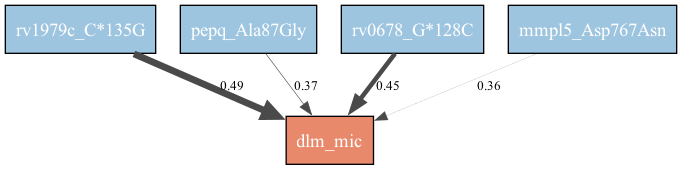

In [2]:
show_graph(f'{LINFIX}/with_lineage', ['dlm_mic'])

In [3]:
parents_of(f'{LINFIX}/with_lineage', 'dlm_mic')

,source,frequency
0,rv1979c_C*135G,0.49
1,rv0678_G*128C,0.45
2,pepq_Ala87Gly,0.37
3,mmpl5_Asp767Asn,0.36
4,mmpl5_Thr794Ile,0.18
5,fgd1_Phe320Phe,0.17
6,lineage_4,0.15
7,fgd1_G*357C,0.14
8,lineage_2,0.10
9,mmpl5_Ile948Val,0.10


## Same model, complete structure

Adds the mutation-mutation and mutation->lineage co-occurrence edges (background), for completeness. Note nothing points from lineage into a mutation.

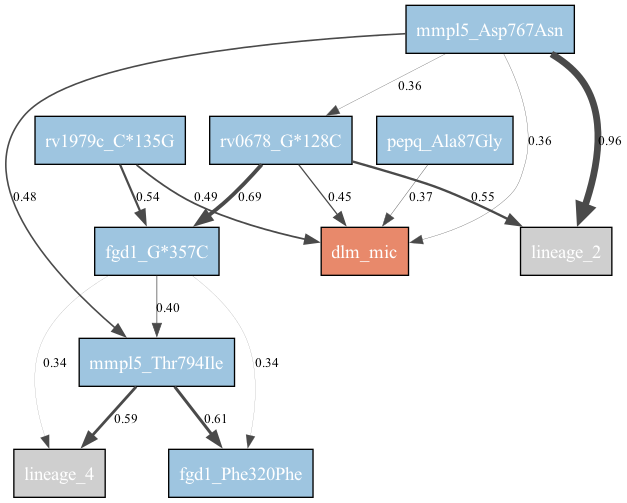

In [4]:
show_graph(f'{LINFIX}/with_lineage', ['dlm_mic'], into_only=False)

## Adjusting resistance type out (type treated as downstream)

Type is defined by resistance to other drugs, so it is a co-selection marker, not a cause; here `type -> MIC` is forbidden and the signal returns to the mutations.

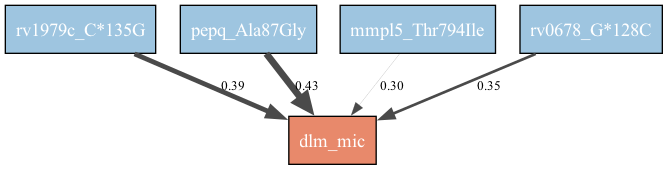

In [5]:
show_graph(f'{LINFIX}/with_lineage_and_type_forbid_type_to_mic', ['dlm_mic'])

In [6]:
parents_of(f'{LINFIX}/with_lineage_and_type_forbid_type_to_mic', 'dlm_mic')

,source,frequency
0,pepq_Ala87Gly,0.43
1,rv1979c_C*135G,0.39
2,rv0678_G*128C,0.35
3,mmpl5_Thr794Ile,0.30
4,mmpl5_Asp767Asn,0.26
5,fgd1_G*357C,0.18
6,fgd1_Phe320Phe,0.18
7,lineage_4,0.10
8,lineage_2,0.10


## What the graph shows

No single mutation -> `dlm_mic` edge clears 0.5: no robust single direct driver. Lineage -> `dlm_mic` is weak (~0.10). Once resistance type is adjusted out, the residual signal sits on `pepq_Ala87Gly` (0.43) and the efflux-cluster variants (`rv1979c`, `rv0678`, `mmpl5`), none reaching 0.5; which one leads depends on the adjustment.